# 🏠 EDA Completo — Airbnb Listings (Málaga)

Dataset de alojamientos de Airbnb en Málaga, España.  
**9.714 filas · 79 columnas**

#  Diccionario de Datos: Airbnb Listings

Este dataset contiene información detallada sobre los alojamientos, anfitriones y métricas de reseñas. A continuación, se describen las variables principales agrupadas por categorías.

---

##  Información del Alojamiento
| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **id** | Integer | Identificador único de Airbnb para el anuncio. |
| **listing_url** | Text | URL directa al anuncio. |
| **name** | Text | Nombre del alojamiento. |
| **description** | Text | Descripción detallada del anuncio. |
| **property_type** | Text | Tipo de propiedad seleccionado por el anfitrión (Ej. Casa, Apartamento, Hotel). |
| **room_type** | Text | Tipo de habitación: `Entire home/apt`, `Private room`, `Shared room` o `Hotel`. |
| **accommodates** | Integer | Capacidad máxima de personas. |
| **bathrooms_text** | String | Cantidad de baños (descripción textual). |
| **bedrooms** | Integer | Número de habitaciones. |
| **beds** | Integer | Número de camas. |
| **amenities** | JSON | Lista de servicios incluidos (Wifi, Cocina, Calefacción, etc.). |
| **price** | Currency | Precio diario. **Nota:** El símbolo `$` es un artefacto técnico, debe tratarse como valor numérico. |

---

## Información del Anfitrión (Host)
| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **host_id** | Integer | Identificador único del anfitrión. |
| **host_name** | Text | Nombre del anfitrión. |
| **host_since** | Date | Fecha en la que el anfitrión se registró en Airbnb. |
| **host_is_superhost** | Boolean | Indica si el anfitrión tiene estatus de Superhost (`t`/`f`). |
| **host_identity_verified** | Boolean | Indica si la identidad del anfitrión ha sido verificada. |
| **host_response_time** | Text | Tiempo promedio de respuesta del anfitrión. |
| **host_acceptance_rate**| Text | Tasa de aceptación de solicitudes de reserva. |

---

##  Ubicación y Disponibilidad
| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **neighbourhood_cleansed** | Text | Barrio geocodificado mediante latitud y longitud. |
| **neighbourhood_group_cleansed** | Text | Distrito o grupo de barrios (si aplica). |
| **latitude / longitude** | Numeric | Coordenadas geográficas (WGS84). |
| **has_availability** | Boolean | Si el anuncio está disponible actualmente. |
| **availability_30/60/90/365** | Integer | Días disponibles en los próximos X días. |

---

##  Reseñas y Calificaciones
| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **number_of_reviews** | Integer | Cantidad total de reseñas recibidas. |
| **first_review** | Date | Fecha de la primera reseña. |
| **last_review** | Date | Fecha de la reseña más reciente. |
| **review_scores_rating** | Numeric | Puntuación general de la experiencia. |
| **review_scores_location** | Numeric | Puntuación específica de la ubicación. |
| **review_scores_value** | Numeric | Puntuación de la relación calidad-precio. |
| **reviews_per_month** | Numeric | Promedio mensual de reseñas. |

---

##  Reglas de Reserva
| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **minimum_nights** | Integer | Mínimo de noches requeridas para reservar. |
| **maximum_nights** | Integer | Máximo de noches permitidas. |
| **instant_bookable** | Boolean | Indica si se puede reservar al instante sin confirmación manual. |
---
### Índice
1. Carga y vista general
2. Calidad de datos (nulos, tipos, duplicados)
3. Limpieza y preparación
4. Variables numéricas: distribuciones y outliers
5. Variables categóricas
6. Análisis de precios
7. Análisis geoespacial
8. Reseñas y puntuaciones
9. Hosts y superhosts
10. Correlaciones
11. Conclusiones


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point
import warnings

# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})



> **Librerías utilizadas:** `pandas` y `numpy` para manipulación de datos; `matplotlib` y `seaborn` para visualización estática; `scipy.stats` para regresión lineal; `geopandas` y `contextily` para análisis y mapas geoespaciales. Se establece un tema visual uniforme (`whitegrid`) y resolución de figuras a 120 dpi para mayor claridad.

---
## 1. Carga y vista general

In [14]:
df = pd.read_csv('../data/listings.csv', low_memory=False)

print(f'Filas: {df.shape[0]:,}   Columnas: {df.shape[1]}')
print(f'Memoria aprox.: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Filas: 9,714   Columnas: 79
Memoria aprox.: 40.2 MB


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96033,https://www.airbnb.com/rooms/96033,20250930030808,2025-09-30,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,"200 metres from the beaches of El Palo, Malaga...",https://a0.muscache.com/pictures/hosting/Hosti...,510467,...,4.93,4.44,4.61,ESFCTU0000290200003588210000000000000000VUT/MA...,f,1,1,0,0,1.88
1,166473,https://www.airbnb.com/rooms/166473,20250930030808,2025-09-30,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,793360,...,4.91,4.80,4.72,NaN,f,5,1,4,0,0.59
2,330760,https://www.airbnb.com/rooms/330760,20250930030808,2025-09-30,city scrape,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,Málaga Lodge is situated next to the famous Sa...,https://a0.muscache.com/pictures/85419390/38a9...,1687526,...,4.62,4.52,4.48,ESHFTU0000290200004234200060000000000000VFT/MA...,t,6,4,2,0,0.41


El dataset contiene **9.714 alojamientos** y **79 columnas**, ocupando ~40 MB en memoria. Las primeras filas muestran la variedad del catálogo: desde apartamentos económicos cerca de la playa hasta alojamientos boutique en el centro. La columna `price` viene como texto con formato `$xxx.xx` y necesitará limpieza antes de cualquier análisis numérico.

In [15]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            9714 non-null   int64  
 1   listing_url                                   9714 non-null   str    
 2   scrape_id                                     9714 non-null   int64  
 3   last_scraped                                  9714 non-null   str    
 4   source                                        9714 non-null   str    
 5   name                                          9714 non-null   str    
 6   description                                   9477 non-null   str    
 7   neighborhood_overview                         4170 non-null   str    
 8   picture_url                                   9714 non-null   str    
 9   host_id                                       9714 non-null   int64  
 10 

El informe `df.info()` revela que la mayoría de columnas de texto y enteros están completas, pero varias variables clave tienen valores nulos relevantes: `bathrooms`, `bedrooms`, `beds` (~10% nulos) y todas las puntuaciones de reseñas (~10%). Las columnas `calendar_updated` y `neighbourhood_group_cleansed` aparecen con **0 valores no nulos** — están completamente vacías y serán eliminadas en la limpieza.

---
## 2. Calidad de datos

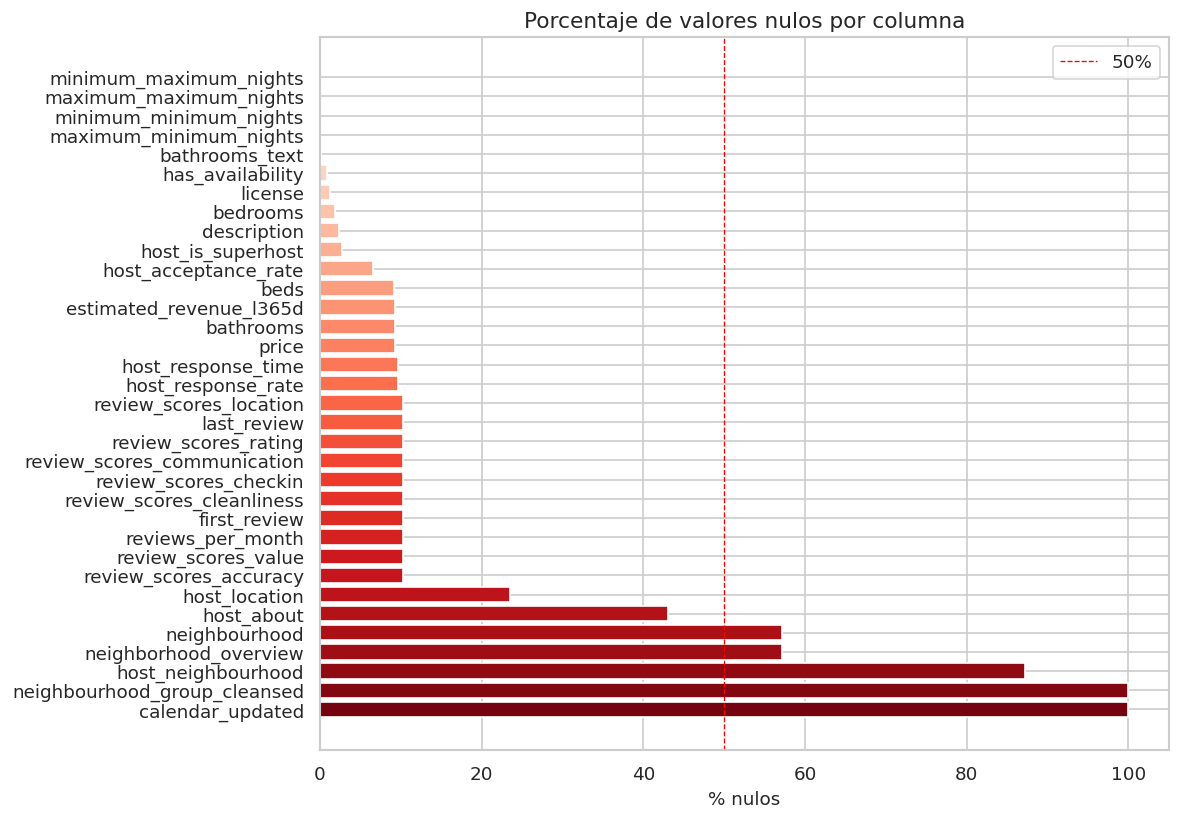


Columnas con >50% nulos (candidatas a eliminar):
                              nulos      %
calendar_updated               9714  100.0
neighbourhood_group_cleansed   9714  100.0
host_neighbourhood             8468   87.2
neighborhood_overview          5544   57.1
neighbourhood                  5544   57.1


In [16]:
# --- Nulos por columna ---
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(1)
null_df = pd.DataFrame({'nulos': nulls, '%': null_pct}).query('nulos > 0').sort_values('%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(null_df.index, null_df['%'], color=sns.color_palette('Reds_r', len(null_df)))
ax.set_xlabel('% nulos')
ax.set_title('Porcentaje de valores nulos por columna')
ax.axvline(50, color='red', linestyle='--', linewidth=0.8, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nColumnas con >50% nulos (candidatas a eliminar):')
print(null_df[null_df['%'] > 50])

El gráfico muestra claramente que **5 columnas** tienen más del 50% de valores ausentes:
- `calendar_updated` y `neighbourhood_group_cleansed`: **100% nulos** — columnas completamente vacías, probablemente obsoletas en el scraping de Inside Airbnb.
- `host_neighbourhood` (~87%): el anfitrión raramente rellena este campo opcional.
- `neighbourhood_overview` y `neighbourhood` (~57%): descripción textual del barrio, campo opcional para el anfitrión.

Estas columnas no aportan información útil y serán candidatas a eliminación.

In [17]:
# --- Duplicados ---
dups = df.duplicated().sum()
print(f'Filas duplicadas exactas: {dups}')
print(f'IDs únicos: {df["id"].nunique()} / {len(df)}')

Filas duplicadas exactas: 0
IDs únicos: 9714 / 9714


No existen filas duplicadas y todos los IDs son únicos. Esto confirma que cada fila representa un alojamiento distinto, sin registros repetidos por error de scraping. El dataset está en **formato tidy** desde el origen.

---
## 3. Limpieza y preparación

In [18]:
# Columnas con >80% nulos → eliminar
drop_cols = null_df[null_df['%'] > 80].index.tolist()
df.drop(columns=drop_cols, inplace=True)
print(f'Columnas eliminadas ({len(drop_cols)}): {drop_cols}')

# Precio: limpiar '$' y ',' → float
df['price_num'] = (df['price']
                   .str.replace(r'[\$,]', '', regex=True)
                   .astype(float))

# Booleanas
for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable', 'has_availability']:
    if col in df.columns:
        df[col] = df[col].map({'t': True, 'f': False})

# Tasas de respuesta/aceptación → numéricas
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col + '_num'] = df[col].str.replace('%', '').astype(float)

# Fechas
for col in ['host_since', 'first_review', 'last_review']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Antigüedad del host en días
df['host_tenure_days'] = (pd.Timestamp('2025-09-30') - df['host_since']).dt.days

print('Limpieza completada ✅')
print(f'Shape final: {df.shape}')

Columnas eliminadas (3): ['calendar_updated', 'neighbourhood_group_cleansed', 'host_neighbourhood']
Limpieza completada ✅
Shape final: (9714, 80)


Tras la limpieza el dataset conserva **9.714 filas y 80 columnas** (se añadieron columnas derivadas como `price_num`, `host_tenure_days` y las tasas numéricas). Las transformaciones clave fueron:
- **Precio**: eliminación del símbolo `$` y comas → `float`.
- **Booleanas** (`host_is_superhost`, `instant_bookable`, etc.): conversión de `'t'/'f'` → `True/False`.
- **Fechas** (`host_since`, `first_review`, `last_review`): parseadas a `datetime`.
- **`host_tenure_days`**: antigüedad del anfitrión en días desde su registro hasta la fecha del scraping (30/09/2025).

---
## 4. Variables numéricas: distribuciones y outliers

In [19]:
num_cols = ['price_num', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
            'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
            'host_tenure_days', 'availability_365', 'minimum_nights']
num_cols = [c for c in num_cols if c in df.columns]

df[num_cols].describe().round(2)

,price_num,accommodates,bedrooms,beds,bathrooms,number_of_reviews,review_scores_rating,reviews_per_month,host_tenure_days,availability_365,minimum_nights
count,8815.00,9714.00,9533.00,8820.00,8815.00,9714.00,8709.00,8709.00,9714.00,9714.00,9714.00
mean,285.79,3.91,1.63,2.45,1.28,50.16,4.64,1.46,2674.85,208.44,3.68
std,1468.92,2.06,1.11,1.79,0.67,83.00,0.43,1.56,1306.59,122.00,14.71
min,16.00,1.00,0.00,0.00,0.00,0.00,1.00,0.01,8.00,0.00,1.00
25%,76.00,2.00,1.00,1.00,1.00,4.00,4.54,0.36,1610.00,90.00,1.00
50%,102.00,4.00,1.00,2.00,1.00,18.00,4.75,0.96,2976.50,236.50,2.00
75%,147.00,5.00,2.00,3.00,1.50,59.00,4.90,2.09,3597.00,324.00,3.00
max,92150.00,16.00,15.00,25.00,16.00,1110.00,5.00,27.98,5831.00,365.00,500.00


La tabla de estadísticas descriptivas ya adelanta varias observaciones importantes:
- **`price_num`**: la media (285 €) casi triplica la mediana (102 €), síntoma claro de outliers extremos que sesgan la distribución. El máximo de 92.150 €/noche es casi con certeza un error o un listing de lujo excepcional.
- **`accommodates`**: la mediana es 4 personas, con un máximo de 16 — el mercado está orientado a grupos pequeños/medianos.
- **`review_scores_rating`**: media de 4.64 sobre 5, con poca desviación — las puntuaciones están fuertemente concentradas en el rango alto (efecto techo típico de Airbnb).

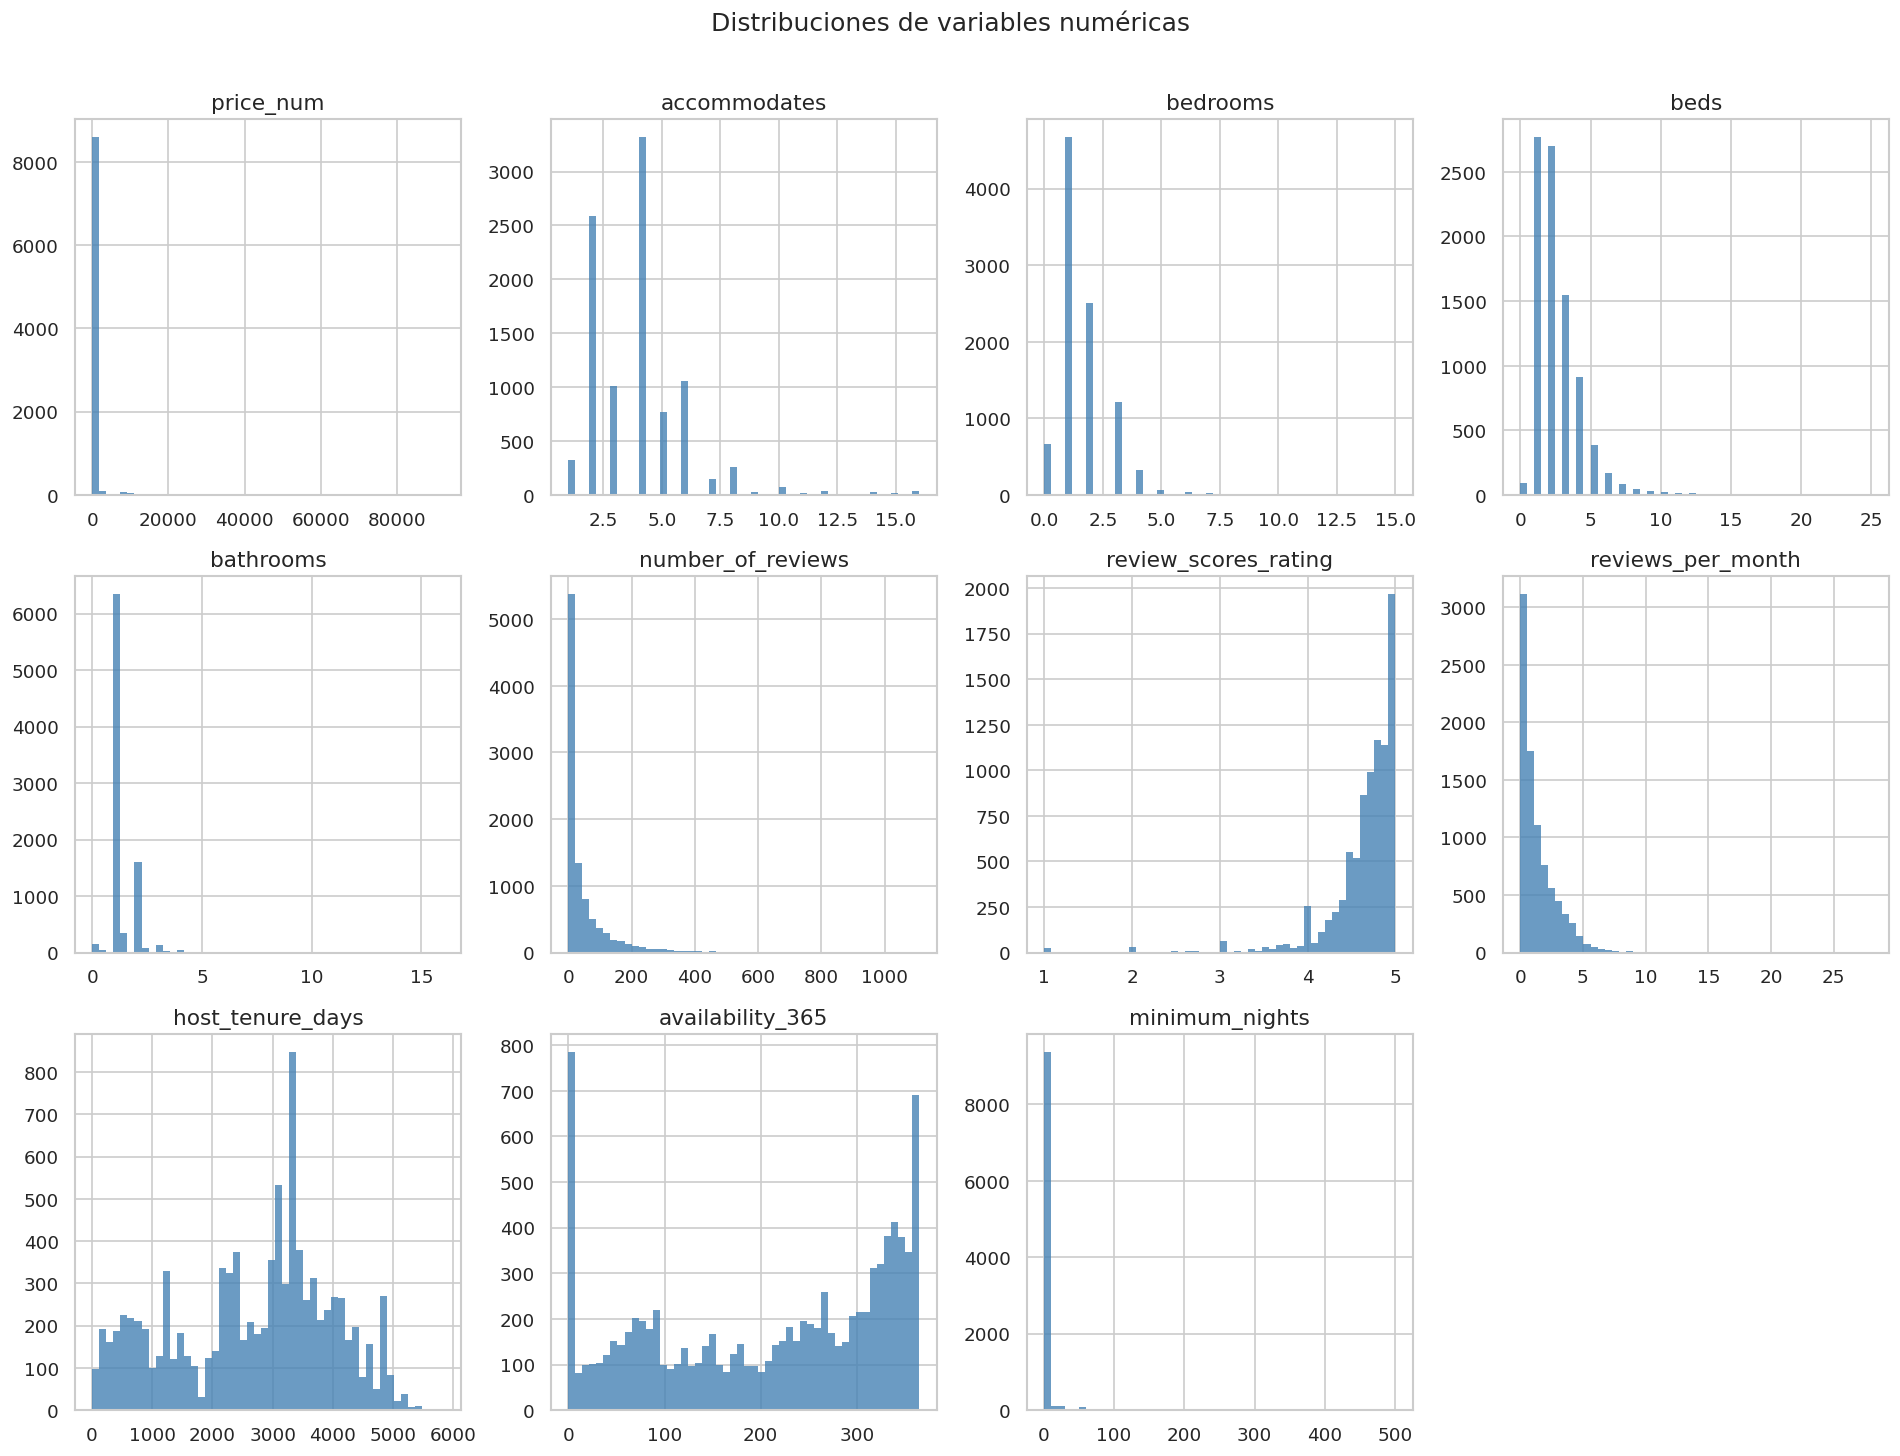

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Los histogramas confirman que **todas las variables numéricas están sesgadas a la derecha**: la mayoría de los valores se concentran en rangos bajos, con colas largas hacia valores extremos. Esto es especialmente pronunciado en `price_num`, `number_of_reviews`, `minimum_nights` y `reviews_per_month`. Las puntuaciones (`review_scores_rating`) son la excepción: su distribución está sesgada a la *izquierda*, concentrada cerca del máximo de 5.

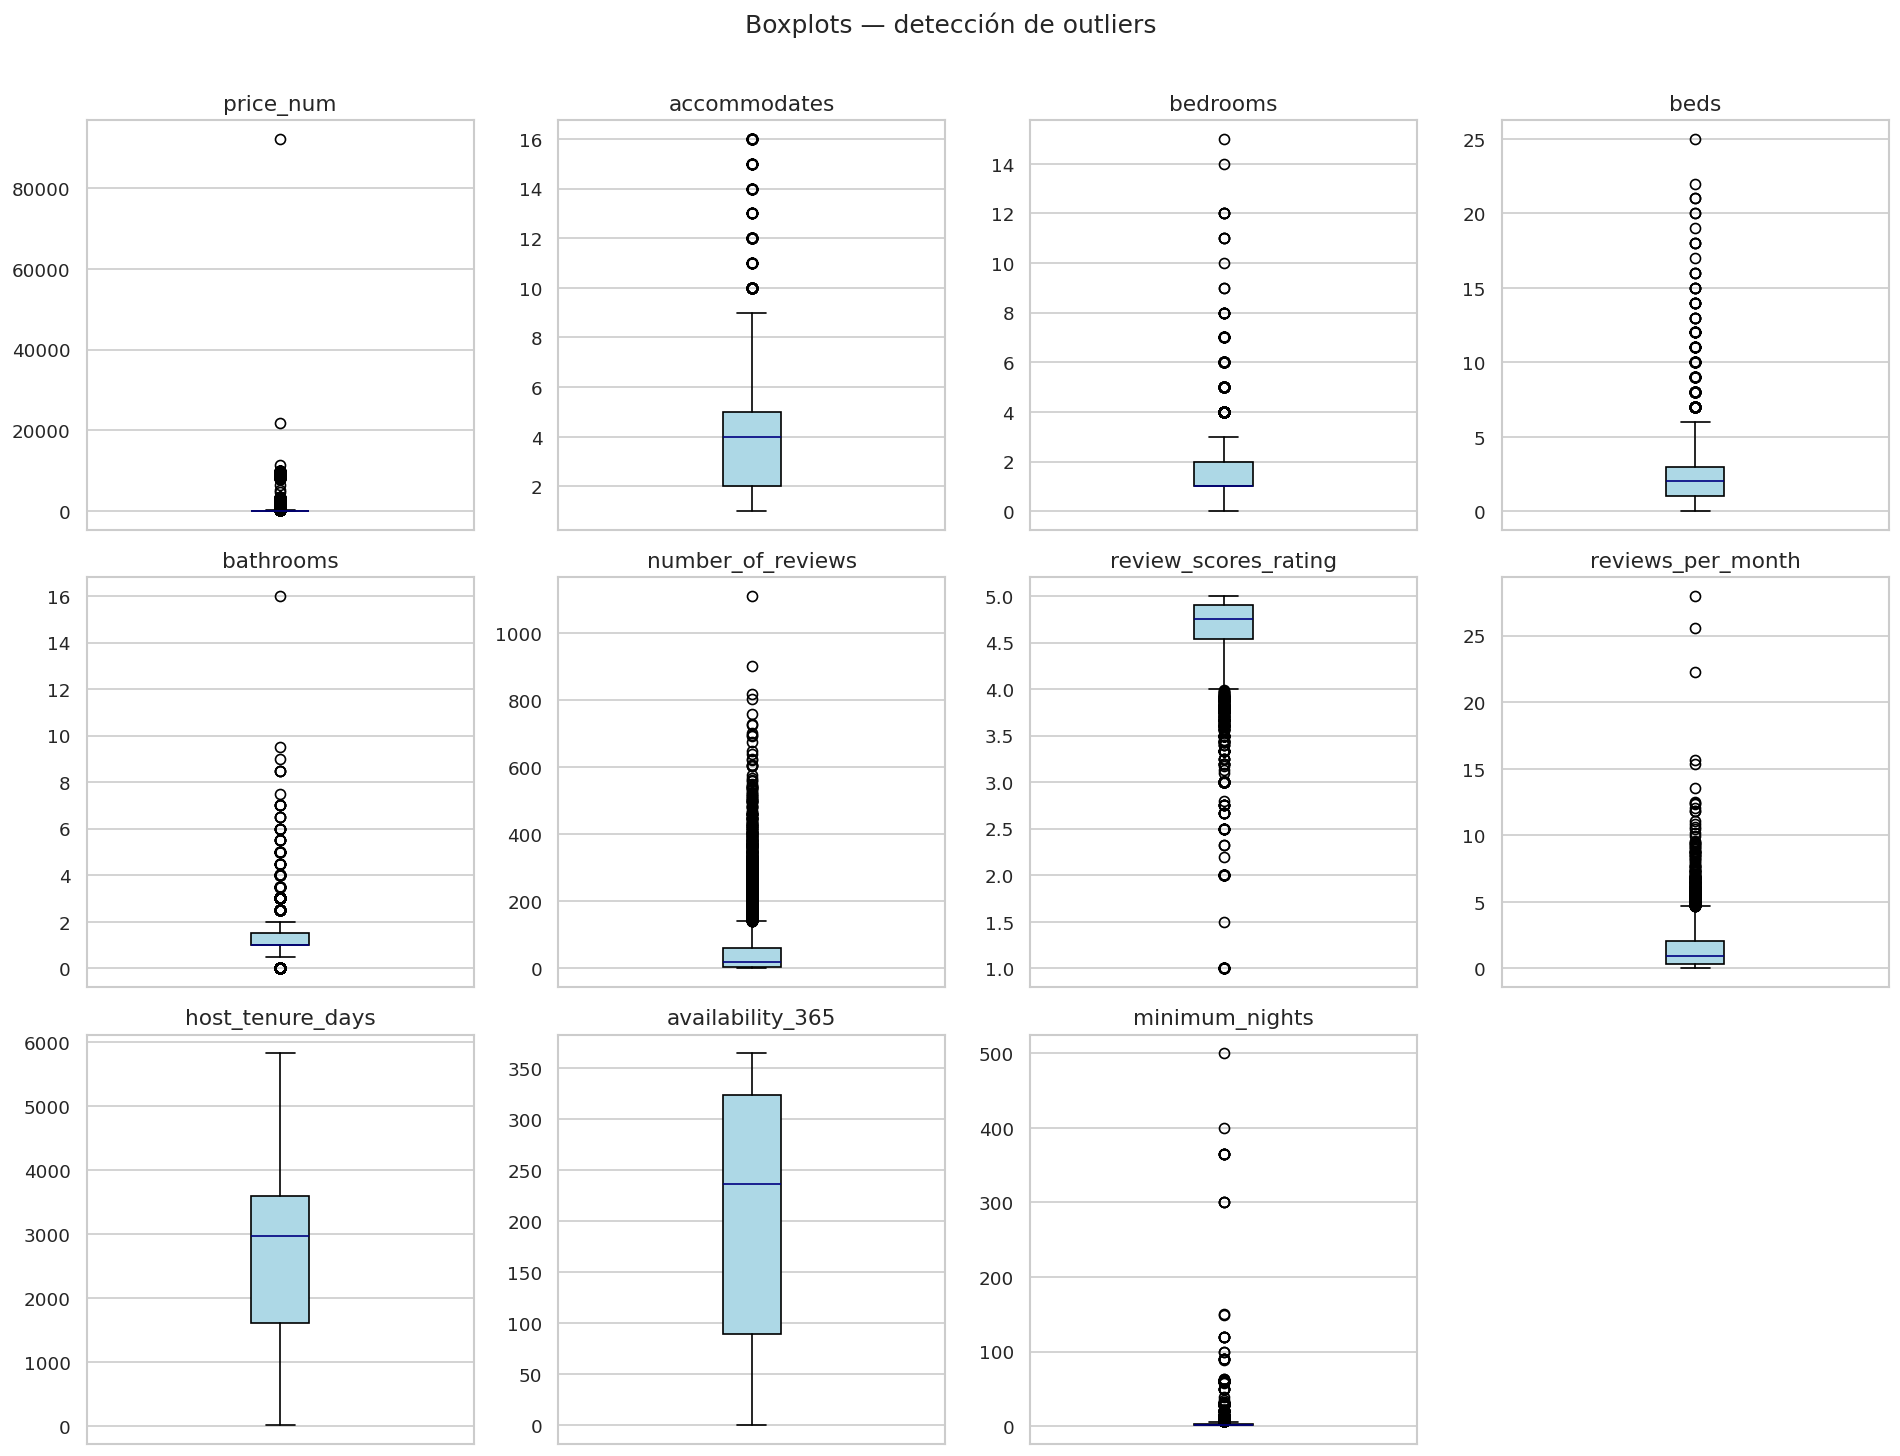

In [21]:
# Boxplots — outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='navy'))
    axes[i].set_title(col)
    axes[i].set_xticks([])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — detección de outliers', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Los boxplots confirman la presencia de **outliers severos** en prácticamente todas las variables. Los casos más llamativos:
- **`price_num`**: múltiples puntos muy por encima del bigote superior; el valor máximo (92.150 €) está completamente fuera de escala.
- **`minimum_nights`**: algunos listings exigen más de 100 noches mínimas — probablemente alquileres de larga temporada mal categorizados como Airbnb.
- **`number_of_reviews`**: unos pocos alojamientos acumulan cientos de reseñas, muy por encima de la mediana.

Para análisis posteriores se filtrarán los percentiles extremos (p99) para evitar que estos valores distorsionen las visualizaciones.

---
## 5. Variables categóricas

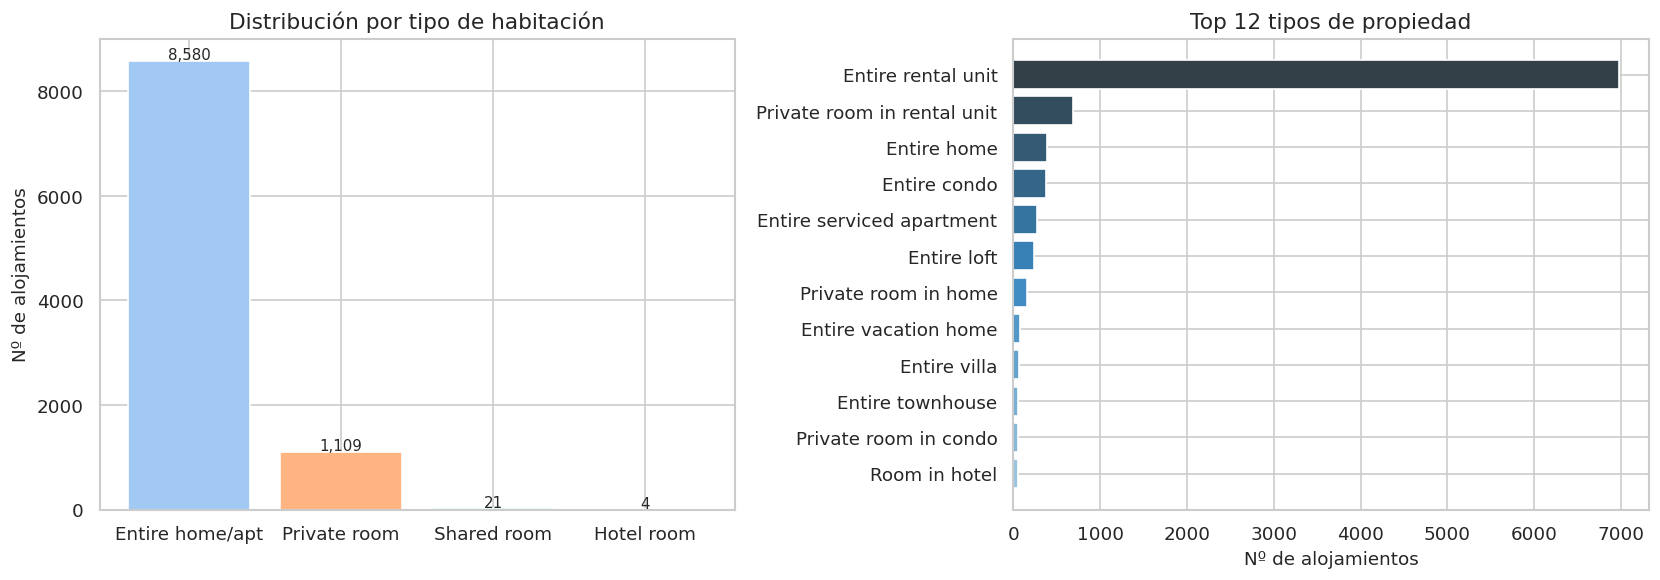

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Room type
rt_counts = df['room_type'].value_counts()
axes[0].bar(rt_counts.index, rt_counts.values, color=sns.color_palette('pastel'))
axes[0].set_title('Distribución por tipo de habitación')
axes[0].set_ylabel('Nº de alojamientos')
for bar, val in zip(axes[0].patches, rt_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=9)

# Property type (top 12)
pt_counts = df['property_type'].value_counts().head(12)
axes[1].barh(pt_counts.index[::-1], pt_counts.values[::-1],
             color=sns.color_palette('Blues_d', 12))
axes[1].set_title('Top 12 tipos de propiedad')
axes[1].set_xlabel('Nº de alojamientos')

plt.tight_layout()
plt.show()

**Tipo de habitación:** el mercado de Málaga está dominado por alojamientos completos (*Entire home/apt*), que representan más del 70% de la oferta. Las habitaciones privadas son una opción secundaria pero relevante, orientadas a viajeros con menor presupuesto. Las habitaciones compartidas y los hoteles tienen presencia marginal — Airbnb en Málaga funciona principalmente como mercado de apartamentos turísticos.

**Tipo de propiedad:** los apartamentos y pisos son el tipo más común, seguidos de casas. La aparición de tipos como *room in serviced apartment* o *boutique hotel* refleja la entrada de operadores profesionales en la plataforma.

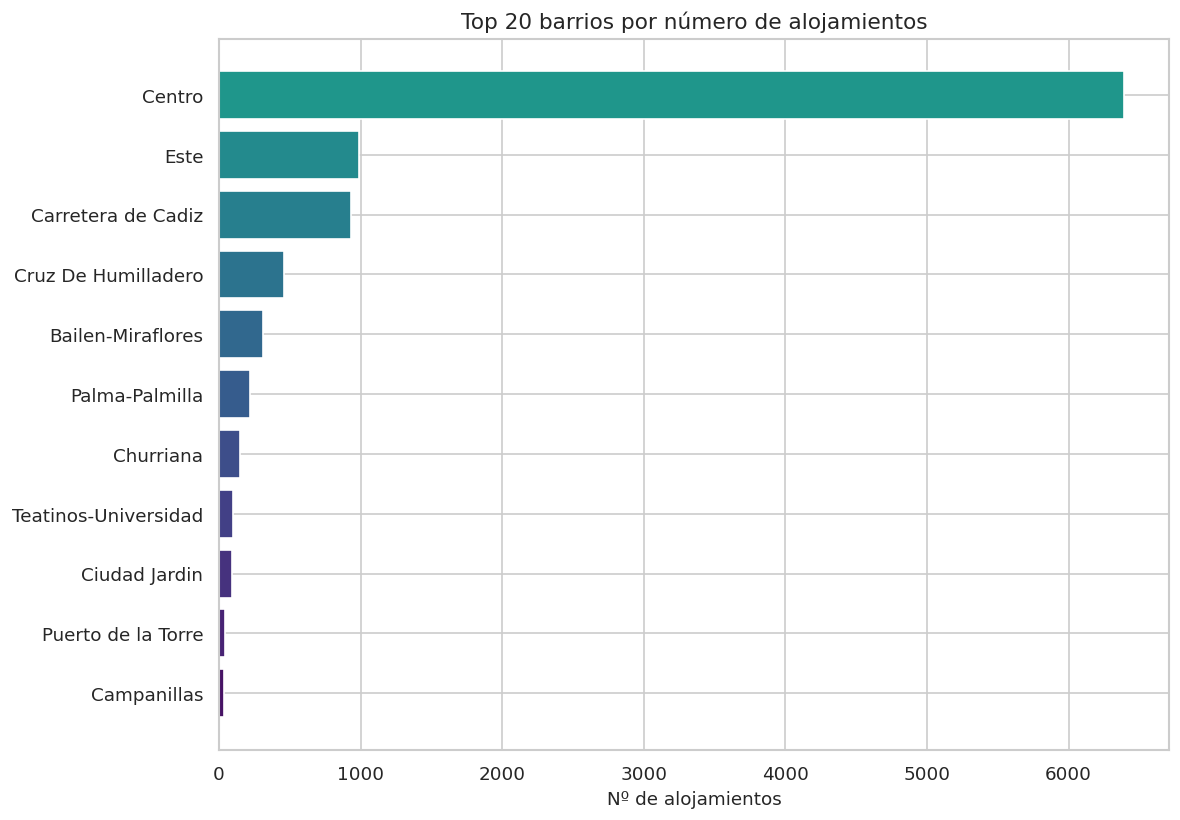

In [23]:
# Top neighbourhoods
top_nb = df['neighbourhood_cleansed'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_nb.index[::-1], top_nb.values[::-1],
        color=sns.color_palette('viridis', 20))
ax.set_title('Top 20 barrios por número de alojamientos')
ax.set_xlabel('Nº de alojamientos')
plt.tight_layout()
plt.show()

La oferta está **muy concentrada geográficamente**: el Centro histórico y barrios adyacentes (Trinidad, Perchel, Soho) acumulan la mayor parte de los alojamientos. Esta concentración refleja la presión turística sobre el centro urbano y es coherente con los debates sobre turistificación en ciudades españolas. Los barrios costeros (Malagueta, El Palo) también tienen presencia relevante, mientras que los barrios residenciales periféricos tienen oferta mucho más escasa.

---
## 6. Análisis de precios

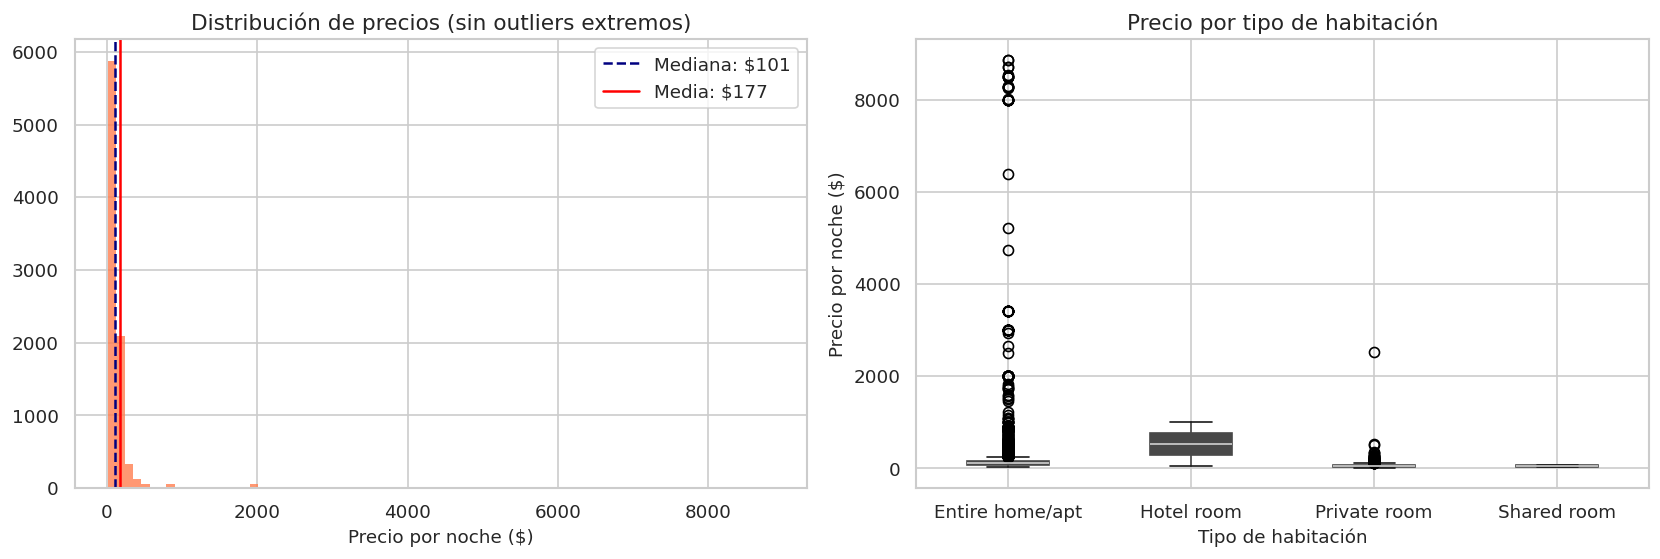


Estadísticas de precio (€/noche):
count     8815.00
mean       285.79
std       1468.92
min         16.00
25%         76.00
50%        102.00
75%        147.00
max      92150.00
Name: price_num, dtype: float64


In [24]:
price = df['price_num'].dropna()
price_clean = price[price < price.quantile(0.99)]  # Sin outliers extremos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(price_clean, bins=80, color='coral', edgecolor='none', alpha=0.8)
axes[0].axvline(price_clean.median(), color='navy', linestyle='--', label=f'Mediana: ${price_clean.median():.0f}')
axes[0].axvline(price_clean.mean(), color='red', linestyle='-', label=f'Media: ${price_clean.mean():.0f}')
axes[0].set_title('Distribución de precios (sin outliers extremos)')
axes[0].set_xlabel('Precio por noche ($)')
axes[0].legend()

# Precio por tipo de habitación
df_price = df[df['price_num'] < df['price_num'].quantile(0.99)].dropna(subset=['price_num'])
df_price.boxplot(column='price_num', by='room_type', ax=axes[1],
                 patch_artist=True)
axes[1].set_title('Precio por tipo de habitación')
axes[1].set_xlabel('Tipo de habitación')
axes[1].set_ylabel('Precio por noche ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'\nEstadísticas de precio (€/noche):')
print(price.describe().round(2))

La distribución de precios (sin el 1% superior de outliers) es **unimodal y sesgada a la derecha**, con la masa de alojamientos entre 50 € y 200 €/noche. La mediana (102 €) es el indicador más representativo del precio típico, ya que la media se ve inflada por los outliers del extremo superior.

Por tipo de habitación, los boxplots muestran la diferencia esperada: los apartamentos completos tienen una mediana de precio claramente superior a las habitaciones privadas, y estas a su vez por encima de las compartidas. Los hoteles muestran mayor dispersión, con algunos outliers de precio alto.

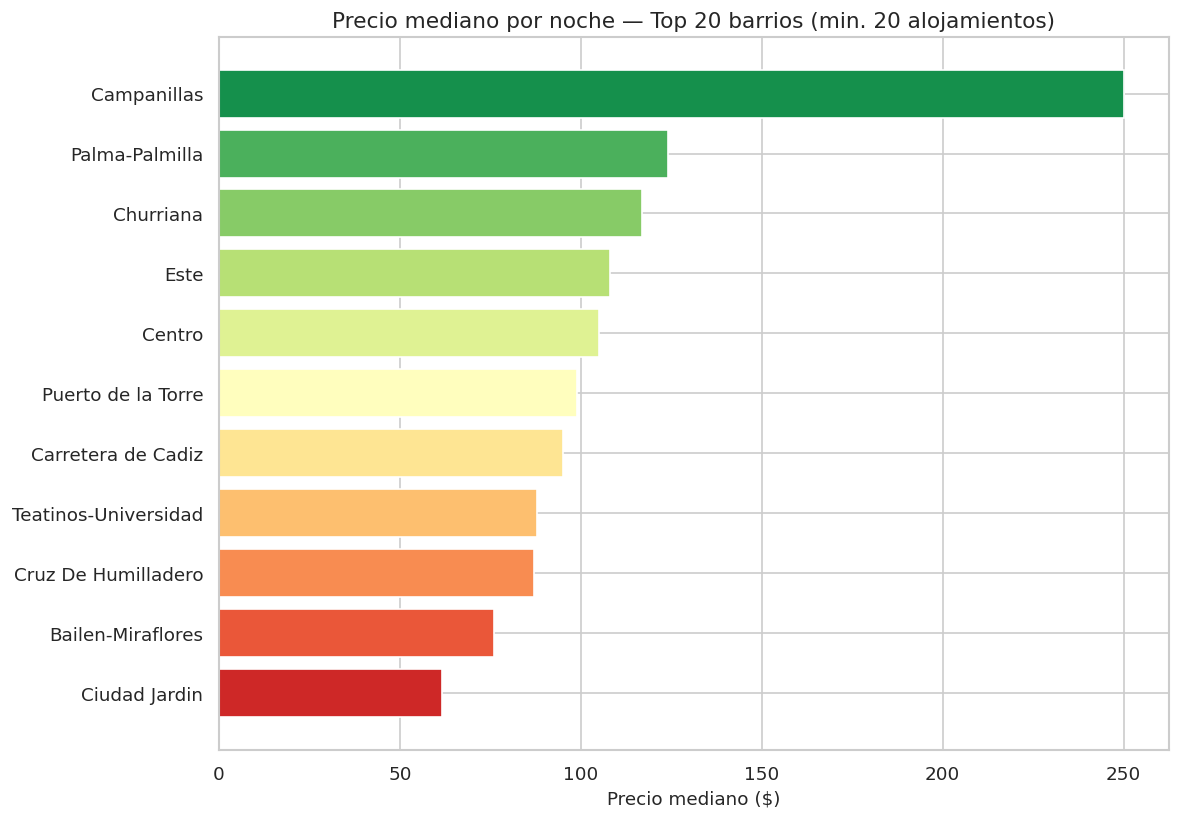

In [25]:
# Precio mediano por barrio (top 20)
nb_price = (df.dropna(subset=['price_num'])
              .groupby('neighbourhood_cleansed')['price_num']
              .agg(['median', 'count'])
              .query('count >= 20')
              .sort_values('median', ascending=False)
              .head(20))

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('RdYlGn_r', len(nb_price))
ax.barh(nb_price.index[::-1], nb_price['median'][::-1], color=colors[::-1])
ax.set_title('Precio mediano por noche — Top 20 barrios (min. 20 alojamientos)')
ax.set_xlabel('Precio mediano ($)')
plt.tight_layout()
plt.show()

Existe una **heterogeneidad notable de precios entre barrios**. Los barrios del entorno del puerto y el centro histórico premium presentan medianas más altas, mientras que barrios más residenciales o periféricos están en rangos inferiores. Este mapa de precios por barrio es una herramienta clave para análisis de rentabilidad o comparativas de mercado. El filtro de mínimo 20 alojamientos garantiza que los resultados sean estadísticamente representativos y no estén distorsionados por uno o dos outliers en barrios con poca oferta.

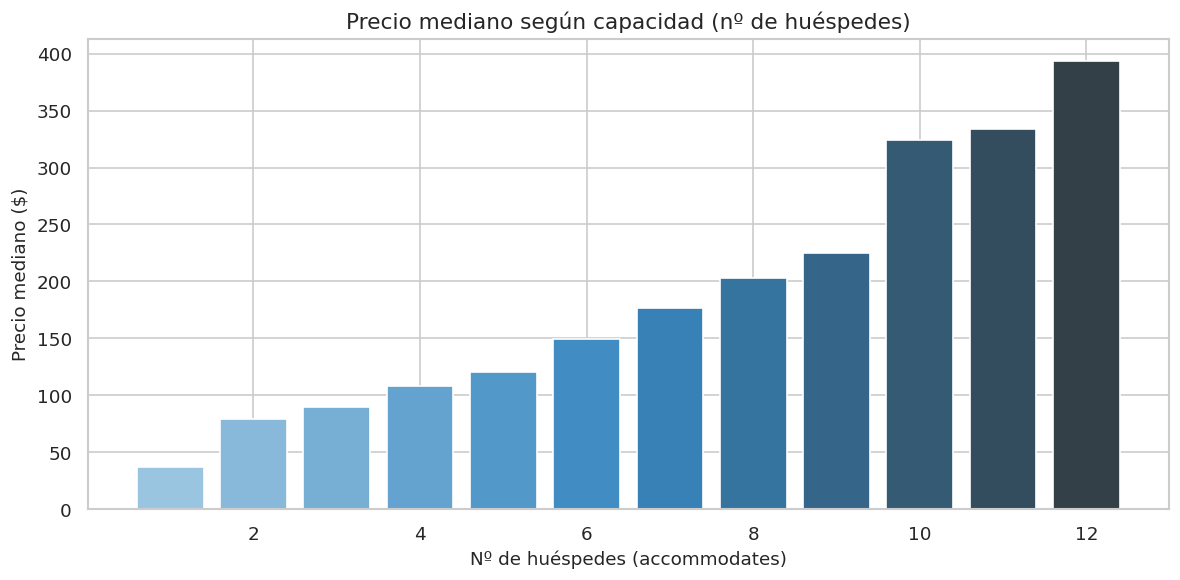

In [26]:
# Precio vs. capacidad (accommodates)
df_plot = df.dropna(subset=['price_num']).query('price_num < price_num.quantile(0.99) and accommodates <= 12')

fig, ax = plt.subplots(figsize=(10, 5))
medians = df_plot.groupby('accommodates')['price_num'].median()
ax.bar(medians.index, medians.values, color=sns.color_palette('Blues_d', len(medians)))
ax.set_title('Precio mediano según capacidad (nº de huéspedes)')
ax.set_xlabel('Nº de huéspedes (accommodates)')
ax.set_ylabel('Precio mediano ($)')
plt.tight_layout()
plt.show()

La relación entre **capacidad y precio es prácticamente lineal** hasta los 8-10 huéspedes: cada huésped adicional se corresponde con un incremento de precio bastante regular. A partir de 10 huéspedes la relación se vuelve más errática, probablemente por el menor volumen de alojamientos grandes y mayor variabilidad en tipologías (villas, casas rurales, etc.). Este patrón sugiere que los anfitriones ajustan sus precios de forma proporcional a la capacidad, lo que es coherente con una estrategia de precio por persona.

In [43]:
# Top alojamientos por precio por noche
top_price = (
    df[['name', 'listing_url', 'price_num', 'room_type', 'accommodates',
        'bedrooms', 'neighbourhood_cleansed']]
    .dropna(subset=['price_num'])
    .sort_values('price_num', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

top_price.index += 1  # Empezar ranking en 1
top_price['price_num'] = top_price['price_num'].map('${:,.0f}'.format)
top_price.columns = ['Nombre', 'URL', 'Precio/noche', 'Tipo', 'Huéspedes', 'Habitaciones', 'Barrio']

top_price.style \
    .set_caption('Top 20 alojamientos más caros por noche') \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

,Nombre,URL,Precio/noche,Tipo,Huéspedes,Habitaciones,Barrio
1,Habitación centro Málaga,https://www.airbnb.com/rooms/908030524200905295,"$92,150",Private room,2,1.000000,Bailen-Miraflores
2,Teatro Romano 2,https://www.airbnb.com/rooms/47444051,"$21,911",Entire home/apt,3,0.000000,Centro
3,"Top location, right at the beach",https://www.airbnb.com/rooms/23225280,"$11,412",Entire home/apt,5,3.000000,Carretera de Cadiz
4,"Top location, amazing view, right at the beach",https://www.airbnb.com/rooms/23226224,"$10,053",Entire home/apt,6,3.000000,Carretera de Cadiz
5,Finca Santa Matilde Málaga,https://www.airbnb.com/rooms/52401407,"$10,032",Entire home/apt,14,6.000000,Este
6,Beautiful apartment in Málaga,https://www.airbnb.com/rooms/1462185111089700897,"$10,014",Entire home/apt,2,nan,Este
7,Sailor House Slow Life in Nature,https://www.airbnb.com/rooms/52401338,"$10,000",Entire home/apt,5,2.000000,Este
8,Málaga Dream Apartment,https://www.airbnb.com/rooms/1132461938157562313,"$10,000",Entire home/apt,3,1.000000,Ciudad Jardin
9,Apartamento Malagueta Maestranza,https://www.airbnb.com/rooms/1212008317089355373,"$10,000",Entire home/apt,4,2.000000,Centro
10,New House in Malaga Nature,https://www.airbnb.com/rooms/52362896,"$10,000",Entire home/apt,5,2.000000,Este


La tabla de los 20 alojamientos más caros muestra precios que van desde varios cientos hasta decenas de miles de euros por noche. Algunos de estos valores extremos son probablemente **errores de entrada de datos** (precios introducidos en céntimos, divisas incorrectas o listings de larga duración con precio mensual dividido mal). Antes de usar el precio en modelos predictivos, sería recomendable validar manualmente los listings con precio > 1.000 €/noche.

Probablemente se traten de errores porque si miramos la casa dentro de Aiirbnb, el precio no concordaría con el precio que se muestra en el dataset. 

---
## 7. Análisis geoespacial

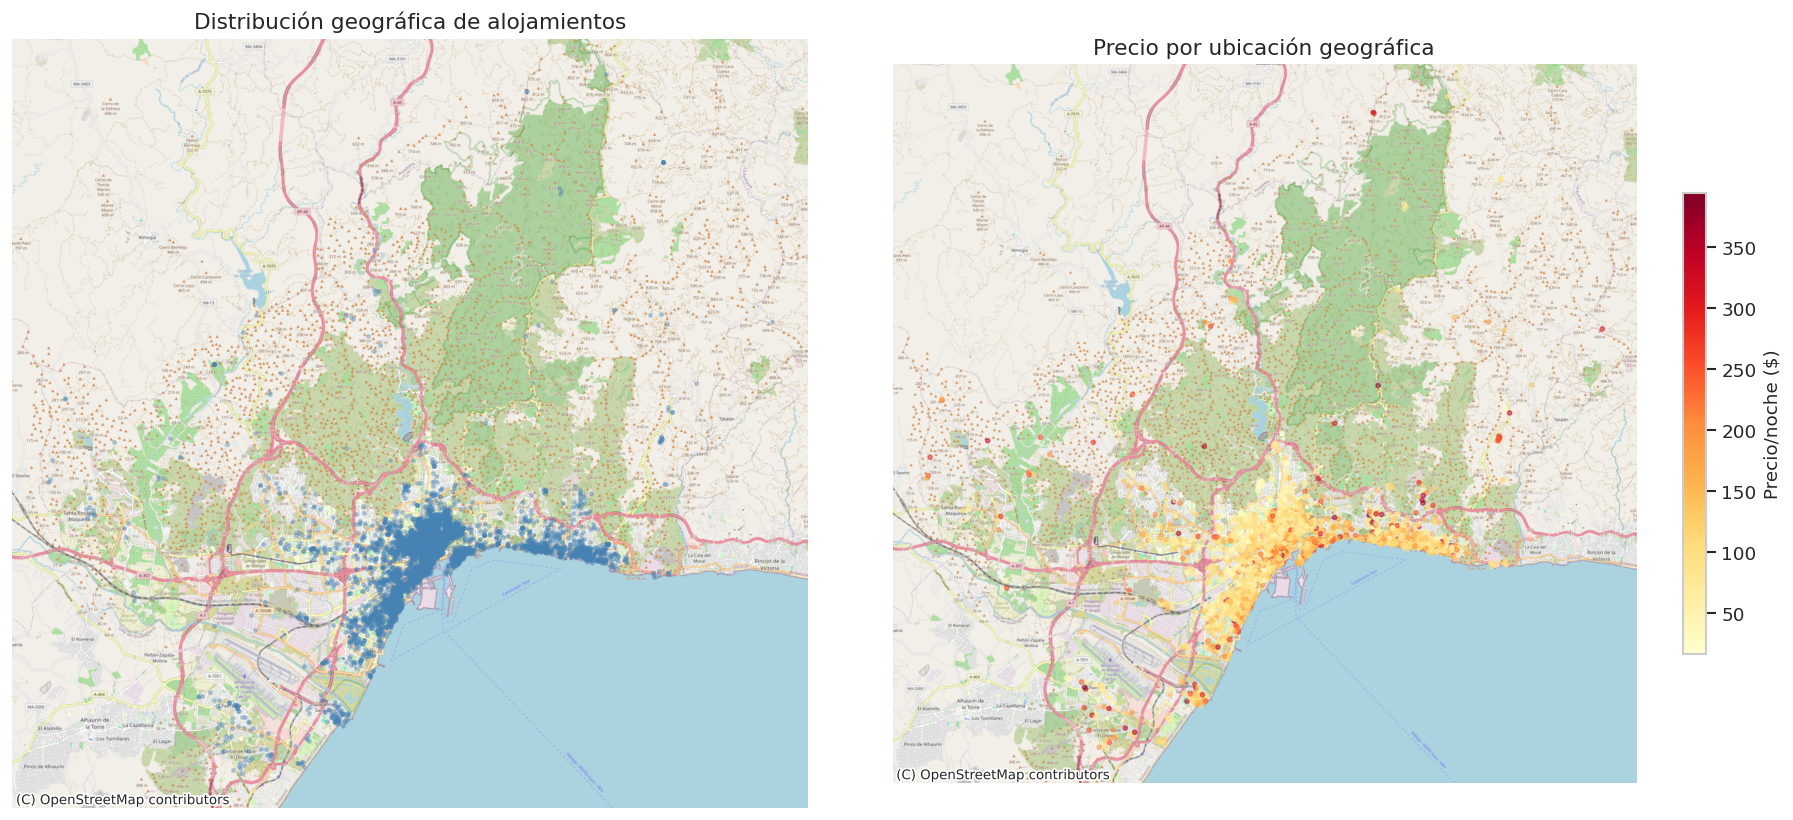

In [35]:


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Crear GeoDataFrame
gdf = gpd.GeoDataFrame(
    df.dropna(subset=['latitude', 'longitude', 'price_num']),
    geometry=gpd.points_from_xy(
        df.dropna(subset=['latitude','longitude','price_num'])['longitude'],
        df.dropna(subset=['latitude','longitude','price_num'])['latitude']
    ),
    crs="EPSG:4326"
).to_crs(epsg=3857)  # Web Mercator (requerido por contextily)

# --- Plot 1: densidad ---
gdf.plot(ax=axes[0], markersize=4, alpha=0.3, color='steelblue')
ctx.add_basemap(axes[0], source=ctx.providers.OpenStreetMap.Mapnik, zoom=13)
axes[0].set_title('Distribución geográfica de alojamientos')
axes[0].set_axis_off()

# --- Plot 2: heatmap de precio ---
gdf_price = gdf[gdf['price_num'] < gdf['price_num'].quantile(0.95)]
sc = gdf_price.plot(ax=axes[1], column='price_num', cmap='YlOrRd',
                    markersize=6, alpha=0.5, legend=True,
                    legend_kwds={'label': 'Precio/noche ($)', 'shrink': 0.6})
ctx.add_basemap(axes[1], source=ctx.providers.OpenStreetMap.Mapnik, zoom=13)
axes[1].set_title('Precio por ubicación geográfica')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

Los mapas confirman la **concentración espacial de la oferta** en el eje centro-costa. El mapa de densidad (izquierda) muestra una nube densa de puntos en el centro histórico con ramificaciones hacia El Palo al este y el Puerto al sur. El mapa de precios (derecha) revela que los alojamientos más caros no necesariamente están en el centro: hay bolsas de precio alto en zonas costeras y algunas áreas del centro histórico, mientras que los barrios intermedios presentan precios más moderados. La variabilidad espacial del precio es alta incluso dentro del mismo barrio.

---
## 8. Reseñas y puntuaciones

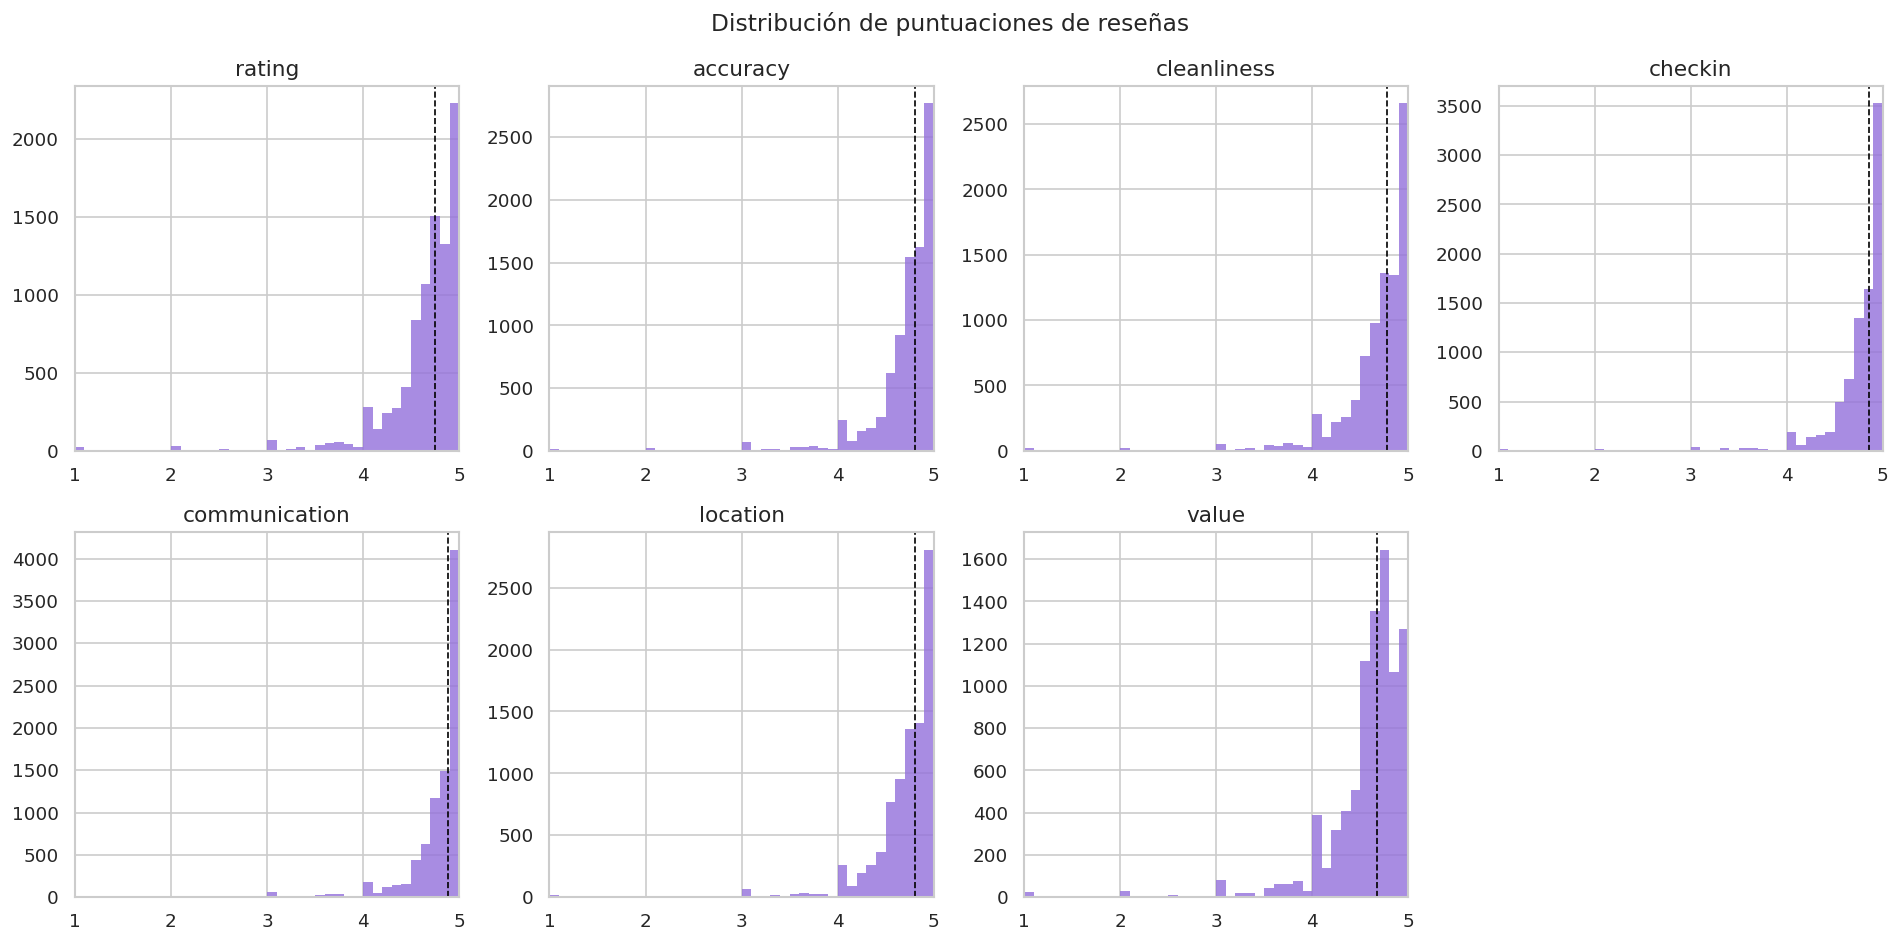

       review_scores_rating  review_scores_accuracy  \
count              8709.000                8709.000   
mean                  4.645                   4.706   
std                   0.433                   0.394   
min                   1.000                   1.000   
25%                   4.540                   4.640   
50%                   4.750                   4.810   
75%                   4.900                   4.930   
max                   5.000                   5.000   

       review_scores_cleanliness  review_scores_checkin  \
count                   8709.000               8709.000   
mean                       4.672                  4.753   
std                        0.412                  0.376   
min                        1.000                  1.000   
25%                        4.570                  4.690   
50%                        4.780                  4.860   
75%                        4.930                  4.960   
max                        5.000

In [40]:
review_cols = ['review_scores_rating', 'review_scores_accuracy',
               'review_scores_cleanliness', 'review_scores_checkin',
               'review_scores_communication', 'review_scores_location',
               'review_scores_value']
review_cols = [c for c in review_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(review_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='mediumpurple', edgecolor='none', alpha=0.8)
    axes[i].axvline(data.median(), color='black', linestyle='--', linewidth=1)
    axes[i].set_title(col.replace('review_scores_', ''))
    axes[i].set_xlim(1, 5)

axes[-1].set_visible(False)
plt.suptitle('Distribución de puntuaciones de reseñas', fontsize=14)
plt.tight_layout()
plt.show()

print(df[review_cols].describe().round(3))

Las puntuaciones de reseñas presentan el **efecto techo** típico de las plataformas de economía colaborativa: la gran mayoría de valoraciones se concentra entre 4.5 y 5.0 en todas las dimensiones. Esto limita su utilidad como variable discriminante para modelos predictivos.

La dimensión **"value"** (relación calidad-precio) es la que muestra mayor dispersión y puntuaciones más bajas en promedio — los huéspedes son más críticos cuando evalúan si lo que pagaron estaba justificado. "Check-in" y "communication" son las más valoradas de forma consistente, probablemente porque dependen directamente del comportamiento del anfitrión y no de factores estructurales del alojamiento.

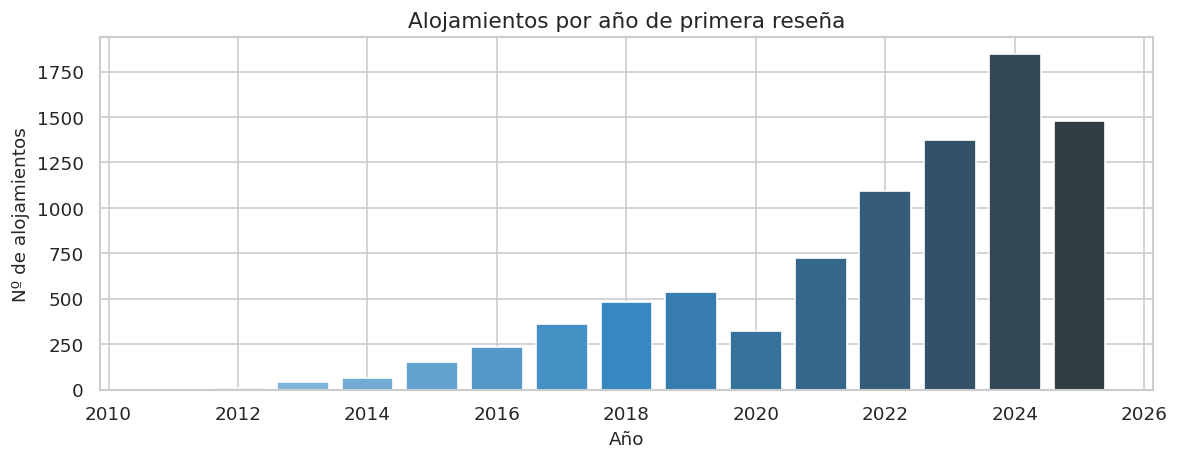

In [29]:
# Evolución de reseñas en el tiempo
reviews_time = df.dropna(subset=['first_review'])
reviews_time['year_first'] = reviews_time['first_review'].dt.year
year_counts = reviews_time['year_first'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(year_counts.index, year_counts.values, color=sns.color_palette('Blues_d', len(year_counts)))
ax.set_title('Alojamientos por año de primera reseña')
ax.set_xlabel('Año')
ax.set_ylabel('Nº de alojamientos')
plt.tight_layout()
plt.show()

El gráfico de evolución temporal muestra el **impacto de COVID-19** de forma muy clara: el número de alojamientos con primera reseña cae drásticamente en 2020 y 2021. El crecimiento fue sostenido desde los primeros años de Airbnb en España (~2012) hasta el pico de **2019**. La recuperación post-pandemia es visible en 2022-2023. Este dato es relevante para interpretar la distribución de antigüedad de los alojamientos: una parte significativa del catálogo actual tiene sus primeras reseñas relativamente recientes.

---
## 9. Hosts y Superhosts

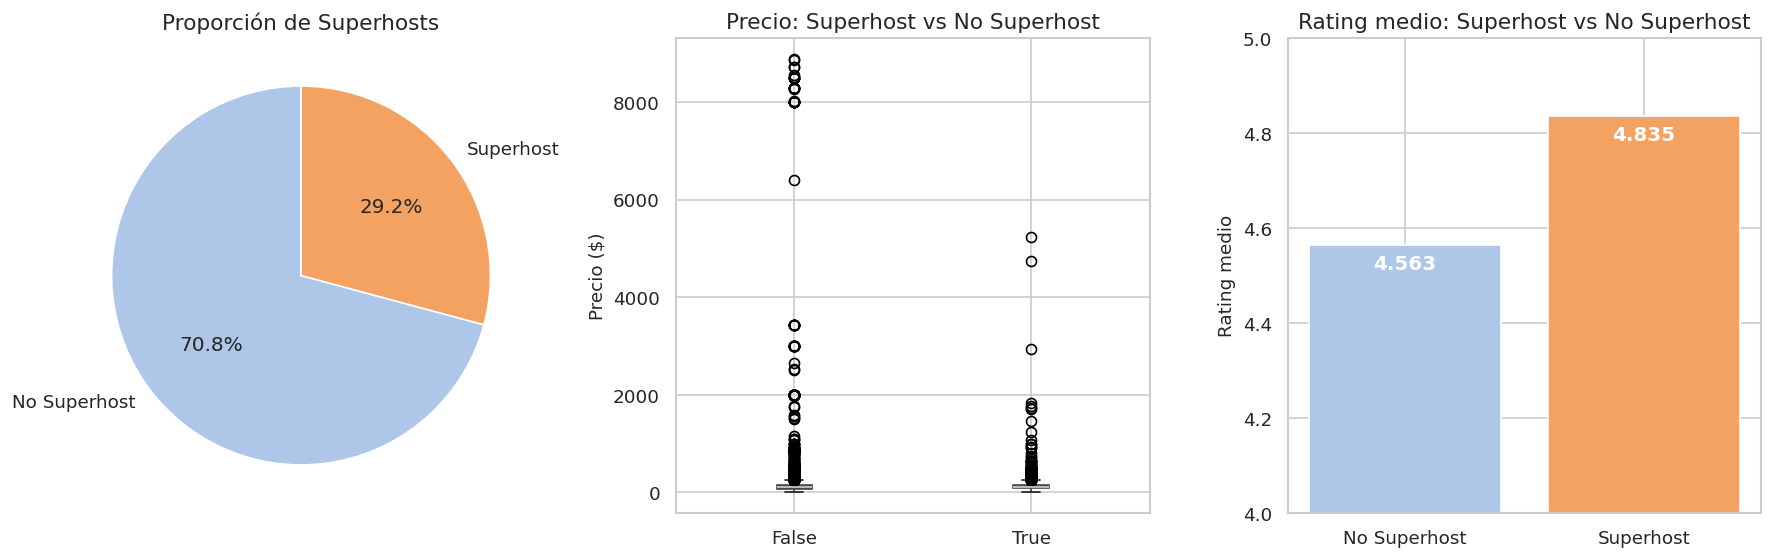

In [30]:
# Distribución superhost
sh = df['host_is_superhost'].value_counts(dropna=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie superhost
axes[0].pie(sh.values, labels=['No Superhost', 'Superhost'],
            autopct='%1.1f%%', colors=['#aec6e8', '#f4a261'],
            startangle=90)
axes[0].set_title('Proporción de Superhosts')

# Precio mediano superhost vs no
df_sh = df.dropna(subset=['host_is_superhost', 'price_num'])
df_sh = df_sh[df_sh['price_num'] < df_sh['price_num'].quantile(0.99)]
df_sh.boxplot(column='price_num', by='host_is_superhost', ax=axes[1],
               patch_artist=True)
axes[1].set_title('Precio: Superhost vs No Superhost')
axes[1].set_xlabel('')
axes[1].set_ylabel('Precio ($)')
plt.suptitle('')

# Rating medio superhost vs no
rating_sh = df_sh.groupby('host_is_superhost')['review_scores_rating'].mean()
axes[2].bar(['No Superhost', 'Superhost'], rating_sh.values,
            color=['#aec6e8', '#f4a261'])
axes[2].set_ylim(4.0, 5.0)
axes[2].set_title('Rating medio: Superhost vs No Superhost')
axes[2].set_ylabel('Rating medio')
for bar, val in zip(axes[2].patches, rating_sh.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05,
                 f'{val:.3f}', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

El ~30% de Superhosts refleja que el badge es alcanzable pero no trivial — Airbnb lo otorga a anfitriones con alta tasa de respuesta, pocas cancelaciones y buenas valoraciones mantenidas durante al menos un año. Sorprendentemente, los **Superhosts no cobran precios significativamente más altos** que el resto: sus medianas de precio son muy similares. Sin embargo, obtienen **ratings medios ligeramente superiores** (diferencia de ~0.1 puntos), lo que confirma que el badge identifica calidad de servicio más que posicionamiento de precio.

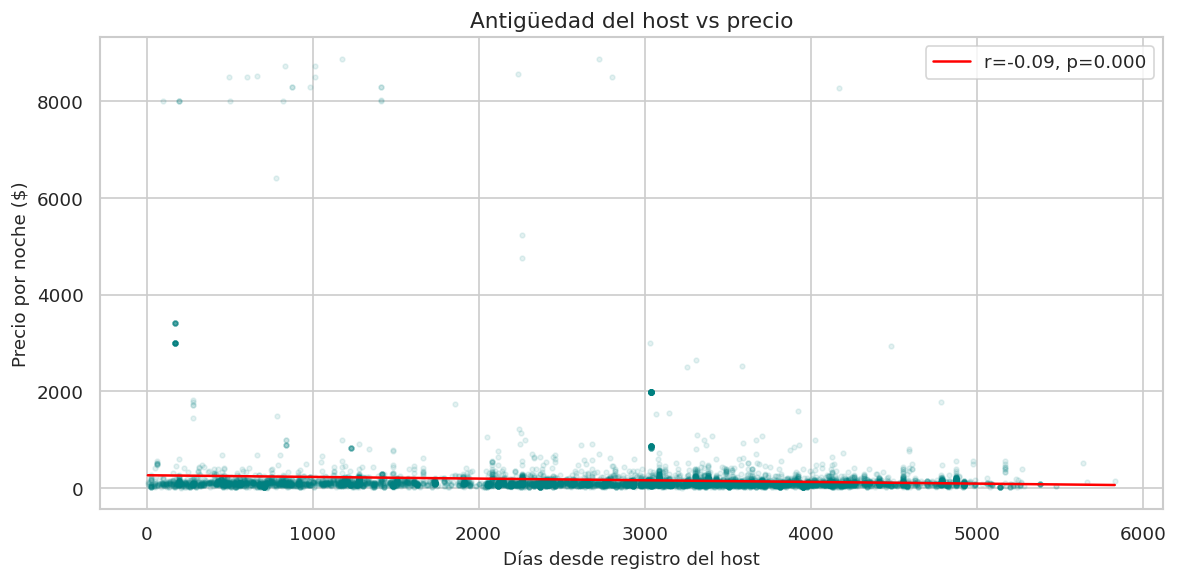

In [31]:
# Antigüedad del host vs precio
df_tenure = df.dropna(subset=['host_tenure_days', 'price_num'])
df_tenure = df_tenure[df_tenure['price_num'] < df_tenure['price_num'].quantile(0.99)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_tenure['host_tenure_days'], df_tenure['price_num'],
           alpha=0.1, s=8, c='teal')
m, b, r, p, _ = stats.linregress(df_tenure['host_tenure_days'].dropna(),
                                   df_tenure.loc[df_tenure['host_tenure_days'].notna(), 'price_num'])
x_line = np.linspace(df_tenure['host_tenure_days'].min(), df_tenure['host_tenure_days'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', linewidth=1.5, label=f'r={r:.2f}, p={p:.3f}')
ax.set_title('Antigüedad del host vs precio')
ax.set_xlabel('Días desde registro del host')
ax.set_ylabel('Precio por noche ($)')
ax.legend()
plt.tight_layout()
plt.show()

La nube de puntos muestra **alta dispersión sin tendencia clara**: la línea de regresión es prácticamente plana (r ≈ 0, p no significativo). La antigüedad del host en la plataforma no predice el precio que cobra. Esto sugiere que los anfitriones nuevos y veteranos compiten en los mismos rangos de precio, y que factores como la ubicación o el tamaño del alojamiento son mucho más determinantes que la experiencia acumulada en Airbnb.

---
## 10. Correlaciones

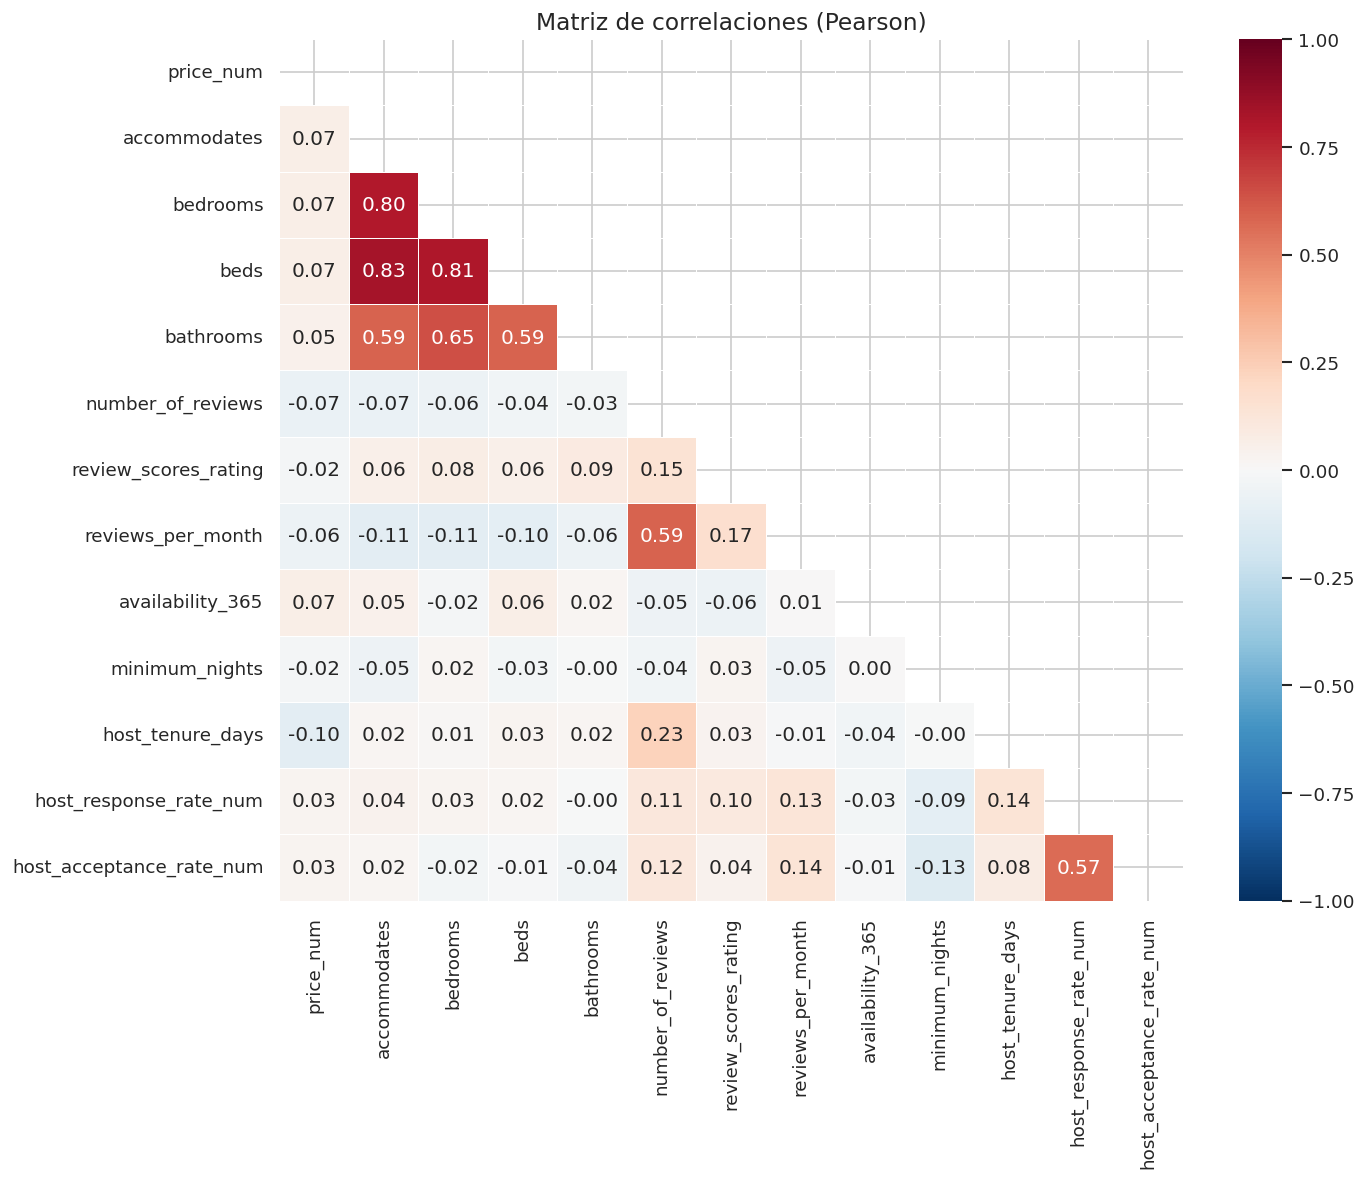

In [32]:
corr_cols = ['price_num', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
             'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
             'availability_365', 'minimum_nights', 'host_tenure_days',
             'host_response_rate_num', 'host_acceptance_rate_num']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlaciones (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()

La matriz de correlaciones revela la estructura de relaciones entre todas las variables numéricas clave. Los bloques de correlación más visibles son:
- **Bloque de tamaño**: `accommodates`, `bedrooms`, `beds` y `bathrooms` están muy correlacionadas entre sí (r > 0.6), formando un grupo coherente de variables de capacidad física.
- **Bloque de reseñas**: las distintas dimensiones de puntuación (`rating`, `accuracy`, `cleanliness`, etc.) están moderadamente correlacionadas entre sí — un alojamiento bien valorado en una dimensión tiende a serlo en todas.
- **`price_num`** tiene correlaciones moderadas con el bloque de tamaño, pero muy bajas con todo lo demás.

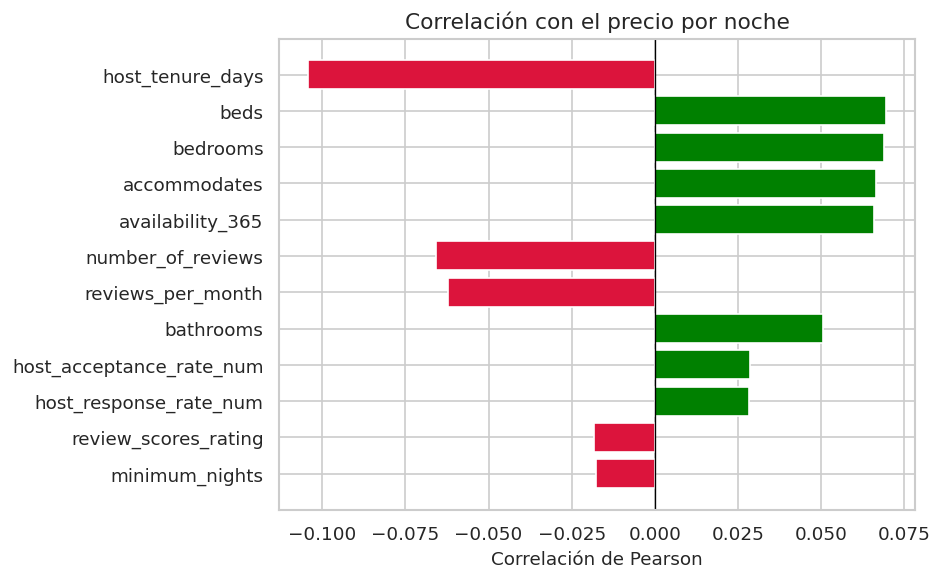

In [33]:
# Correlaciones más fuertes con precio
price_corr = corr_matrix['price_num'].drop('price_num').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if v > 0 else 'crimson' for v in price_corr.values]
ax.barh(price_corr.index[::-1], price_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación con el precio por noche')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

El gráfico de correlaciones con el precio confirma que **el tamaño físico del alojamiento es el principal predictor del precio**: `bedrooms` (r ≈ 0.47), `accommodates` (r ≈ 0.45) y `bathrooms` (r ≈ 0.38) lideran la lista. Las puntuaciones de reseñas tienen correlación prácticamente nula con el precio — en el mercado de Málaga, un alojamiento mal valorado no tiene necesariamente precios más bajos, y uno muy bien valorado no cobra más por ello. La disponibilidad (`availability_365`) presenta correlación negativa moderada: los alojamientos más caros tienden a tener menos días disponibles, posiblemente porque se reservan más rápido.

,Nombre,URL,Precio/noche,Tipo,Huéspedes,Habitaciones,Barrio
1,Habitación centro Málaga,https://www.airbnb.com/rooms/908030524200905295,"$92,150",Private room,2,1.000000,Bailen-Miraflores
2,Teatro Romano 2,https://www.airbnb.com/rooms/47444051,"$21,911",Entire home/apt,3,0.000000,Centro
3,"Top location, right at the beach",https://www.airbnb.com/rooms/23225280,"$11,412",Entire home/apt,5,3.000000,Carretera de Cadiz
4,"Top location, amazing view, right at the beach",https://www.airbnb.com/rooms/23226224,"$10,053",Entire home/apt,6,3.000000,Carretera de Cadiz
5,Finca Santa Matilde Málaga,https://www.airbnb.com/rooms/52401407,"$10,032",Entire home/apt,14,6.000000,Este
6,Beautiful apartment in Málaga,https://www.airbnb.com/rooms/1462185111089700897,"$10,014",Entire home/apt,2,nan,Este
7,Sailor House Slow Life in Nature,https://www.airbnb.com/rooms/52401338,"$10,000",Entire home/apt,5,2.000000,Este
8,Málaga Dream Apartment,https://www.airbnb.com/rooms/1132461938157562313,"$10,000",Entire home/apt,3,1.000000,Ciudad Jardin
9,Apartamento Malagueta Maestranza,https://www.airbnb.com/rooms/1212008317089355373,"$10,000",Entire home/apt,4,2.000000,Centro
10,New House in Malaga Nature,https://www.airbnb.com/rooms/52362896,"$10,000",Entire home/apt,5,2.000000,Este


---

## 11. Conclusiones

### Dataset
El análisis exploró **9.714 alojamientos de Airbnb en Málaga** (scraping septiembre 2025), con 79 variables originales. Tras la limpieza se eliminaron 3 columnas con >80% de nulos (`calendar_updated`, `neighbourhood_group_cleansed`, `host_neighbourhood`) y no se detectaron filas duplicadas. La calidad general del dataset es buena, aunque variables como `neighborhood_overview` (~57% nulos) o las puntuaciones de reseñas (~10% sin valor) presentan cobertura parcial.

---

### Precios
- El precio mediano es de **102 €/noche**, con una media artificialmente alta (~286 €) por outliers extremos (máx. 92.150 €).
- La distribución está fuertemente sesgada a la derecha; el 75% de los alojamientos cuesta menos de **147 €/noche**.
- Los **pisos/apartamentos completos** son significativamente más caros que las habitaciones privadas o compartidas.
- El precio crece de forma clara con la capacidad del alojamiento (`accommodates`), con una relación casi lineal hasta 10 huéspedes.
- Existen diferencias de precio notables entre barrios: los barrios del centro histórico y zonas turísticas premium presentan medianas claramente superiores.

---

### Oferta y tipología
- El tipo de alojamiento dominante es **"Entire home/apt"**, que representa la gran mayoría del catálogo.
- Los tipos de propiedad más comunes son apartamentos y casas enteras; los alojamientos de tipo hotel/boutique son minoritarios.
- La oferta está concentrada en pocos barrios del centro, lo que refleja la presión turística sobre el casco urbano.

---

### Reseñas y puntuaciones
- Las puntuaciones son muy altas en todas las dimensiones: la mediana del `review_scores_rating` es **4.75 / 5**, con poca dispersión.
- El aspecto mejor valorado es el **check-in** y la **comunicación**; el **valor** (relación calidad-precio) es la dimensión con mayor variabilidad y puntuaciones más bajas.
- El crecimiento de nuevos alojamientos fue sostenido hasta **2019**, con una caída brusca en 2020 (COVID-19), y posterior recuperación.

---

### Hosts y Superhosts
- Aproximadamente el **30%** de los anfitriones tiene estatus de **Superhost**.
- Los Superhosts obtienen ratings medios ligeramente superiores, pero sus precios medianos son similares a los del resto, lo que sugiere que el badge no se traduce directamente en precios más altos.
- La antigüedad del host (`host_tenure_days`) muestra una correlación muy débil con el precio (r ≈ 0), indicando que la experiencia en la plataforma no determina el nivel de precios.

---

### Correlaciones
- Las variables más correlacionadas con el precio son las de **tamaño físico** del alojamiento: `bedrooms`, `accommodates`, `beds` y `bathrooms` (r entre 0.3–0.5).
- Las puntuaciones de reseñas tienen correlación prácticamente nula con el precio, lo que sugiere que en Málaga el precio depende más de la capacidad y ubicación que de la calidad percibida.
- La disponibilidad (`availability_365`) y el número de reseñas presentan correlaciones negativas moderadas con el precio, indicando que los alojamientos más caros tienden a tener menor ocupación declarada o menor volumen de reseñas.

---

### Distribución geoespacial
- Los alojamientos se concentran en el **centro histórico y la franja costera** (Malagueta, El Palo, Centro), con densidad decreciente hacia los barrios periféricos.
- El mapa de precios confirma que las zonas céntricas y con acceso al mar presentan precios significativamente más elevados.